In [1]:
# Importing the pandas library for data manipulation and analysis
import pandas as pd

# Importing the numpy library for numerical operations
import numpy as np


# Importing matplotlib's pyplot module for basic plotting
import matplotlib.pyplot as plt

# Importing seaborn for advanced statistical data visualization (built on top of matplotlib)
import seaborn as sns

# Suppressing warning messages (useful for cleaner outputs during analysis)
import warnings
warnings.filterwarnings('ignore')  # This line disables warning messages that might pop up from pandas/numpy, etc.

In [2]:
# Reading a CSV file from the specified path and loading it into a pandas DataFrame called 'df'
# 'r' before the string indicates a raw string, which treats backslashes as literal characters (avoiding escape sequences)
df = pd.read_csv(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\data\seive_percentage.csv")
df_grad = pd.read_csv(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\data\gradistat.csv")

In [3]:
# Use the same sieve sizes and columns as defined earlier
sieve_sizes_microns = np.array([2000, 1000, 500, 250, 125, 63, 1])
phi_sizes = -np.log2(sieve_sizes_microns / 1000.0)
sieve_columns = [
    "sieve_2um_perc", "sieve_1um_perc", "sieve_500um_perc",
    "sieve_250um_perc", "sieve_125um_perc", "sieve_63um_perc", "sieve_pan_perc"
]

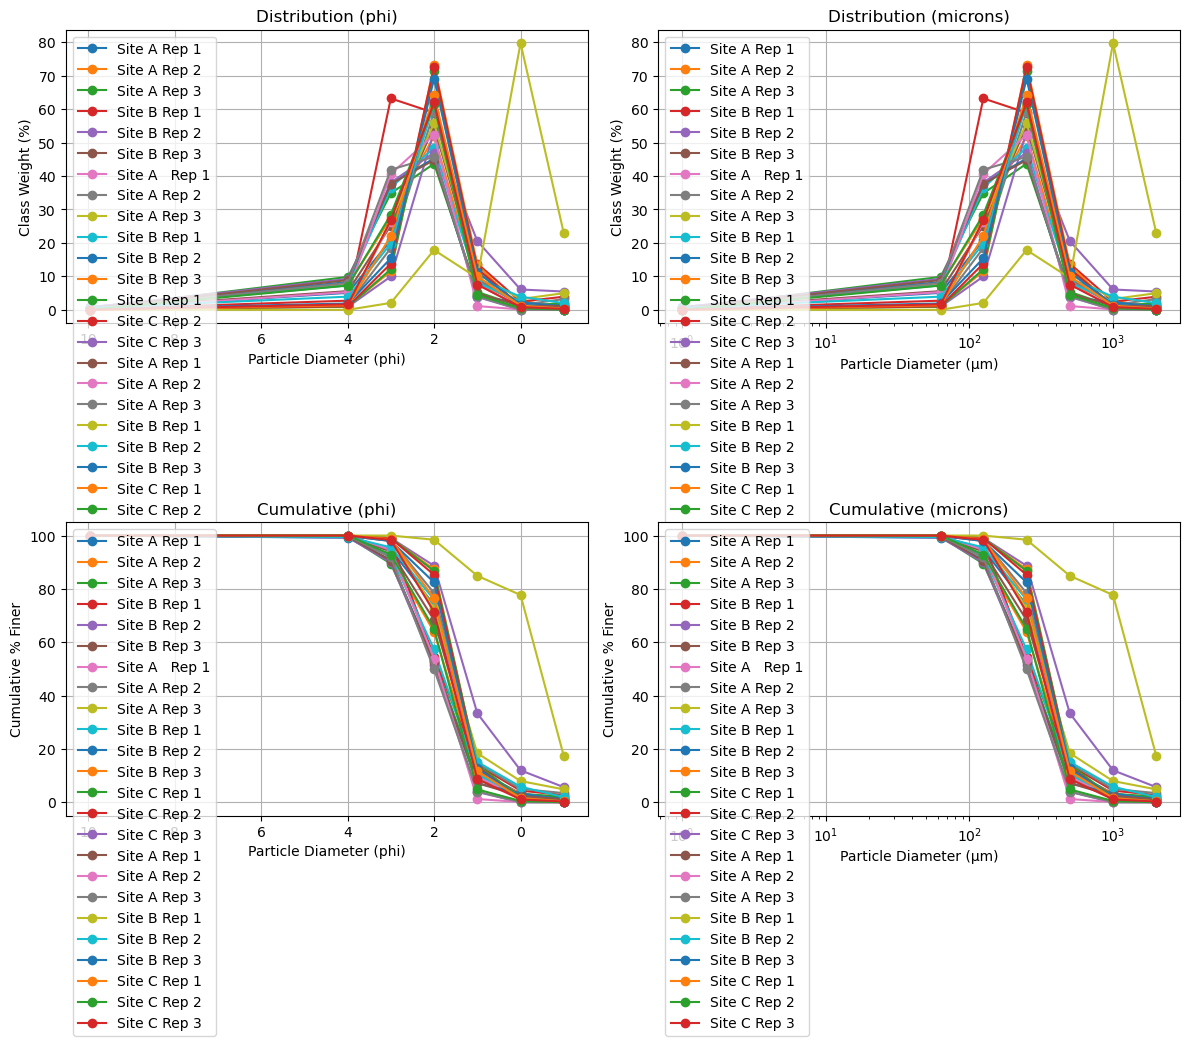

In [4]:
# Create a 2x2 grid of subplots to display grain size distribution plots
# figsize=(12, 10) defines the size of the entire figure in inches (width x height)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Loop through each sample (row) in the original DataFrame 'df'
for _, row in df.iterrows():
    # Extract grain size percentages for each sieve from the row
    weights = row[sieve_columns].values

    # Calculate cumulative percentage (% finer than each sieve size)
    # This helps assess sediment sorting and distribution patterns
    cum_weights = np.cumsum(weights) / np.sum(weights) * 100

    # Create a label for the plot legend using site and replicate information
    label = f"Site {row['site']} Rep {row['replicate']}"

    # Plot 1: Grain size distribution using phi units (smaller particles = higher phi)
    axs[0, 0].plot(phi_sizes, weights, marker='o', label=label)

    # Plot 2: Grain size distribution using actual particle diameter in microns
    axs[0, 1].plot(sieve_sizes_microns, weights, marker='o', label=label)

    # Plot 3: Cumulative % finer (phi scale)
    axs[1, 0].plot(phi_sizes, cum_weights, marker='o', label=label)

    # Plot 4: Cumulative % finer (micron scale)
    axs[1, 1].plot(sieve_sizes_microns, cum_weights, marker='o', label=label)

# ----------------------------
# Format each subplot for clarity
# ----------------------------

# Top-left: Distribution (phi)
axs[0, 0].set_title("Distribution (phi)")  # Title of subplot
axs[0, 0].set_xlabel("Particle Diameter (phi)")  # x-axis label
axs[0, 0].set_ylabel("Class Weight (%)")  # y-axis label
axs[0, 0].invert_xaxis()  # phi scale decreases left to right
axs[0, 0].legend()  # Add legend with sample labels
axs[0, 0].grid(True)  # Add grid lines for readability

# Top-right: Distribution (microns)
axs[0, 1].set_title("Distribution (microns)")
axs[0, 1].set_xlabel("Particle Diameter (µm)")
axs[0, 1].set_ylabel("Class Weight (%)")
axs[0, 1].set_xscale("log")  # Use logarithmic scale for particle size
axs[0, 1].legend()
axs[0, 1].grid(True)

# Bottom-left: Cumulative (phi)
axs[1, 0].set_title("Cumulative (phi)")
axs[1, 0].set_xlabel("Particle Diameter (phi)")
axs[1, 0].set_ylabel("Cumulative % Finer")
axs[1, 0].invert_xaxis()
axs[1, 0].legend()
axs[1, 0].grid(True)

# Bottom-right: Cumulative (microns)
axs[1, 1].set_title("Cumulative (microns)")
axs[1, 1].set_xlabel("Particle Diameter (µm)")
axs[1, 1].set_ylabel("Cumulative % Finer")
axs[1, 1].set_xscale("log")
axs[1, 1].legend()
axs[1, 1].grid(True)

# Adjust the spacing between subplots to prevent overlapping labels/titles
plt.tight_layout()

# Show all the subplots
plt.show()

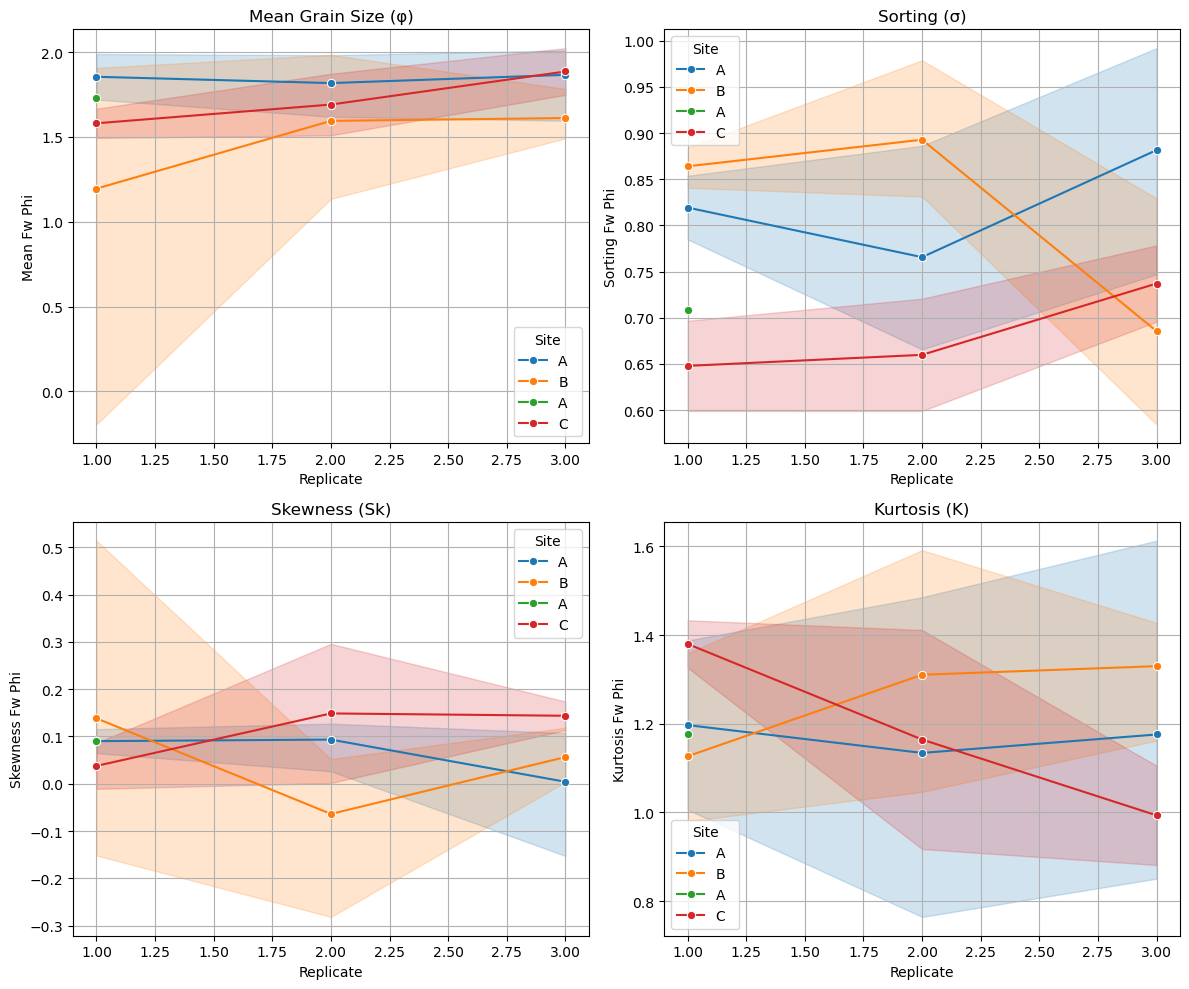

In [5]:
# Set up a 2x2 grid of subplots for visualizing each Gradistat parameter
# figsize sets the overall size of the entire figure in inches
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# List of Gradistat parameters to plot
parameters = ['mean_fw_phi', 'sorting_fw_phi', 'skewness_fw_phi', 'kurtosis_fw_phi']

# Corresponding titles for each subplot
titles = ['Mean Grain Size (φ)', 'Sorting (σ)', 'Skewness (Sk)', 'Kurtosis (K)']

# Loop over each subplot axis, parameter, and its title
for ax, param, title in zip(axs.flat, parameters, titles):
    # Plot a line plot for each site across replicates using Seaborn
    # x-axis: replicates, y-axis: parameter value, hue: different site groups
    sns.lineplot(data=df_grad, x='replicate', y=param, hue='site', marker='o', ax=ax)
    
    # Set the title of the subplot
    ax.set_title(title)
    
    # Label the x-axis
    ax.set_xlabel("Replicate")
    
    # Label the y-axis (formatted nicely from the parameter name)
    ax.set_ylabel(param.replace('_', ' ').title())
    
    # Add gridlines for better readability
    ax.grid(True)
    
    # Add a legend with the title "Site"
    ax.legend(title='Site')

# Adjust the layout to prevent overlapping elements
plt.tight_layout()

# Display the full figure
plt.show()